# Etapa 2 — Modelado con Validación Segura
**Pipeline + GridSearchCV + Evaluación Completa**  
Construye el modelo final y lo evalúa con métricas profesionales.  
Al final exporta `app/model.joblib` para ser servido por la API.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib, os
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix,
    classification_report, roc_curve, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')
print('Librerías cargadas ✓')

Librerías cargadas ✓


## 1. Carga y Preprocesamiento

In [2]:
df = pd.read_csv('../heart.csv')

# Encoding de variables categóricas
cat_cols = df.select_dtypes(include='object').columns.tolist()
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

# ✅ División ANTES de cualquier transformación
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Dataset: {df.shape[0]} pacientes, {df.shape[1]} columnas')
print(f'Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras')
print(f'Features tras encoding: {X.shape[1]}')
print(f'Balance test — Sin enfermedad: {(y_test==0).sum()} | Con enfermedad: {(y_test==1).sum()}')

Dataset: 918 pacientes, 12 columnas
Train: 734 muestras | Test: 184 muestras
Features tras encoding: 15
Balance test — Sin enfermedad: 82 | Con enfermedad: 102


## 2. Pipeline con GridSearchCV — Modelo Final (GradientBoosting)

In [3]:
# GradientBoosting fue el mejor en el ranking del Notebook 1
pipe = Pipeline([
    ('scaler', MinMaxScaler()),
    ('clf', GradientBoostingClassifier(random_state=42))
])

param_grid = {
    'clf__n_estimators':  [50, 100, 200],
    'clf__learning_rate': [0.05, 0.1, 0.2],
    'clf__max_depth':     [3, 4, 5]
}

grid_search = GridSearchCV(
    pipe, param_grid,
    cv=5, scoring='roc_auc',
    n_jobs=-1, verbose=1
)

print('Buscando mejores hiperparámetros...')
grid_search.fit(X_train, y_train)

print(f'\nMejores parámetros: {grid_search.best_params_}')
print(f'Mejor AUC en validación cruzada (5-fold): {grid_search.best_score_:.4f}')

Buscando mejores hiperparámetros...
Fitting 5 folds for each of 27 candidates, totalling 135 fits

Mejores parámetros: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 50}
Mejor AUC en validación cruzada (5-fold): 0.9284


## 3. Evaluación en el Conjunto de Test

In [4]:
best_model = grid_search.best_estimator_
y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)
acc = accuracy_score(y_test, y_pred)

print('=' * 45)
print('   MÉTRICAS EN TEST SET (datos no vistos)')
print('=' * 45)
print(f'AUC-ROC:  {auc:.4f}')
print(f'Accuracy: {acc:.4f}  ({acc*100:.1f}%)')
print()
print('Reporte de Clasificación:')
print(classification_report(
    y_test, y_pred,
    target_names=['Sin Enfermedad (0)', 'Con Enfermedad (1)']
))

   MÉTRICAS EN TEST SET (datos no vistos)
AUC-ROC:  0.9372
Accuracy: 0.8913  (89.1%)

Reporte de Clasificación:
                    precision    recall  f1-score   support

Sin Enfermedad (0)       0.89      0.87      0.88        82
Con Enfermedad (1)       0.89      0.91      0.90       102

          accuracy                           0.89       184
         macro avg       0.89      0.89      0.89       184
      weighted avg       0.89      0.89      0.89       184



## 4. Matriz de Confusión y Curva ROC

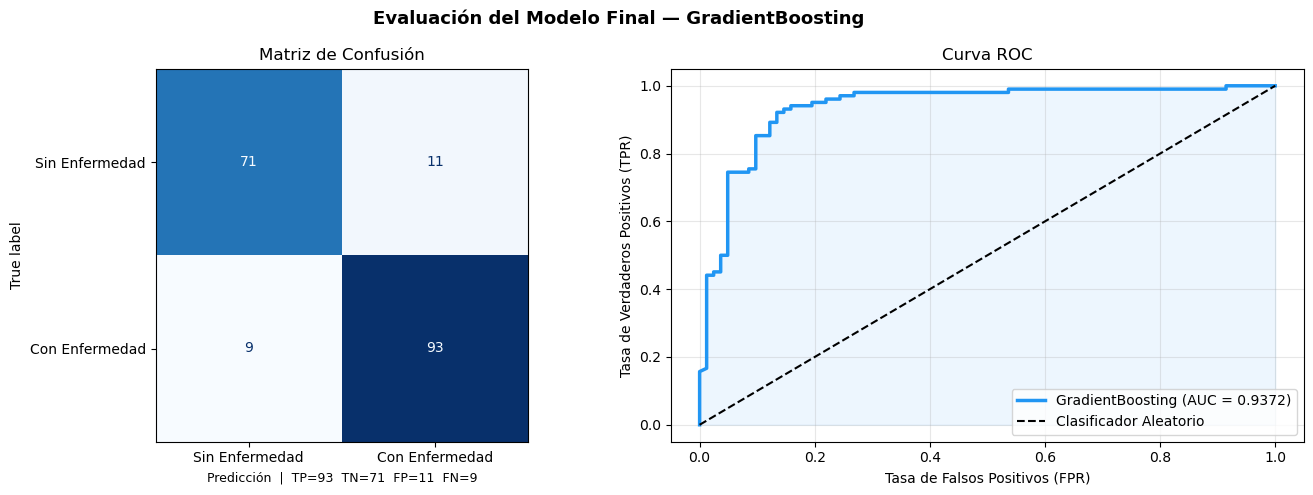

Gráfico guardado: model_evaluation.png ✓


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evaluación del Modelo Final — GradientBoosting', fontsize=13, fontweight='bold')

# --- Matriz de Confusión ---
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Sin Enfermedad', 'Con Enfermedad']
)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión', fontsize=12)

# Anotaciones adicionales
tn, fp, fn, tp = cm.ravel()
axes[0].set_xlabel(
    f'Predicción  |  TP={tp}  TN={tn}  FP={fp}  FN={fn}',
    fontsize=9
)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#2196F3', lw=2.5,
             label=f'GradientBoosting (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Clasificador Aleatorio')
axes[1].fill_between(fpr, tpr, alpha=0.08, color='#2196F3')
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].set_title('Curva ROC', fontsize=12)
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado: model_evaluation.png ✓')

## 5. Validación Cruzada Adicional (10-fold)

In [6]:
cv_scores = cross_val_score(
    best_model, X, y,
    cv=10, scoring='roc_auc', n_jobs=-1
)

print('=== VALIDACIÓN CRUZADA 10-FOLD ===')
print(f'Scores: {cv_scores.round(4)}')
print(f'Media:  {cv_scores.mean():.4f}')
print(f'Std:    {cv_scores.std():.4f}')
print(f'IC 95%: [{cv_scores.mean()-2*cv_scores.std():.4f},'
      f' {cv_scores.mean()+2*cv_scores.std():.4f}]')
print()
print('Interpretación:')
print(f'  El modelo tiene una capacidad discriminativa '
      f'de {cv_scores.mean()*100:.1f}% (AUC promedio).')
print(f'  La desviación estándar de {cv_scores.std():.4f} '
      f'indica que el modelo es {'estable' if cv_scores.std() < 0.03 else "variable"} entre folds.')

=== VALIDACIÓN CRUZADA 10-FOLD ===
Scores: [0.9498 0.978  0.9527 0.9689 0.9254 0.9082 0.9723 0.8355 0.8627 0.8751]
Media:  0.9228
Std:    0.0479
IC 95%: [0.8270, 1.0187]

Interpretación:
  El modelo tiene una capacidad discriminativa de 92.3% (AUC promedio).
  La desviación estándar de 0.0479 indica que el modelo es variable entre folds.


## 6. Exportar Modelo para la API

In [7]:
os.makedirs('../app', exist_ok=True)
joblib.dump(best_model, '../app/model.joblib')

size_kb = os.path.getsize('../app/model.joblib') / 1024
print(f'Modelo exportado: app/model.joblib ({size_kb:.1f} KB) ✓')
print()
print(f'Features esperadas por el modelo ({len(X.columns)}):')
for i, col in enumerate(X.columns):
    print(f'  [{i:02d}] {col}')
print()
print('Ejemplo de llamada a la API:')
sample = X_test.iloc[0].values.tolist()
print(f'  POST /predict')
print(f'  {{"features": {sample}}}')

Modelo exportado: app/model.joblib (77.5 KB) ✓

Features esperadas por el modelo (15):
  [00] Age
  [01] RestingBP
  [02] Cholesterol
  [03] FastingBS
  [04] MaxHR
  [05] Oldpeak
  [06] Sex_M
  [07] ChestPainType_ATA
  [08] ChestPainType_NAP
  [09] ChestPainType_TA
  [10] RestingECG_Normal
  [11] RestingECG_ST
  [12] ExerciseAngina_Y
  [13] ST_Slope_Flat
  [14] ST_Slope_Up

Ejemplo de llamada a la API:
  POST /predict
  {"features": [np.int64(46), np.int64(115), np.int64(0), np.int64(0), np.int64(113), np.float64(1.5), np.True_, np.False_, np.False_, np.False_, np.True_, np.False_, np.True_, np.True_, np.False_]}
